# Design files: Quads design (3dp pla + blue shims) for multiloading source cloaking


## Imports

In [1]:
from mechanicalmetamaterialcloaks.utils import load_data
from scripts.fabrication import generate_blocks_continuous_bond_lines_drawing
from problems.quads_dynamic_load_shielding_source_multi_loading import OptimizationProblem
from pathlib import Path

import jax.numpy as jnp


## Paths

In [2]:
# Where to load/save data
data_folder = Path("../../../data/quads_shielding_multi_loading_source_3dp_pla_shims_4_loads")


## Problem info

NOTE: Either define the problem info here or load it from an optimization file.

In [4]:
# NOTE: Units are mm, N, s

# Retrieve design info from optimization data
optimization_filename = f"opt_integrated_with_angle_30_and_length_5_constraints_quads_15x15_amplitude_4.50_loading_rate_2.0_initial_angle_20.0_clamping_corners_True_damping_scaling_1.0"
optimization = OptimizationProblem.from_dict(
    load_data(
        f"{data_folder}/{optimization_filename}.pkl",
    )
)
problem = optimization.forward_problem
# Set up the forward problem to get the geometry
problem.setup()


Setup intact case dynamics
Setup the solver of the shielding cloak dynamics


## Sketch with labeled units

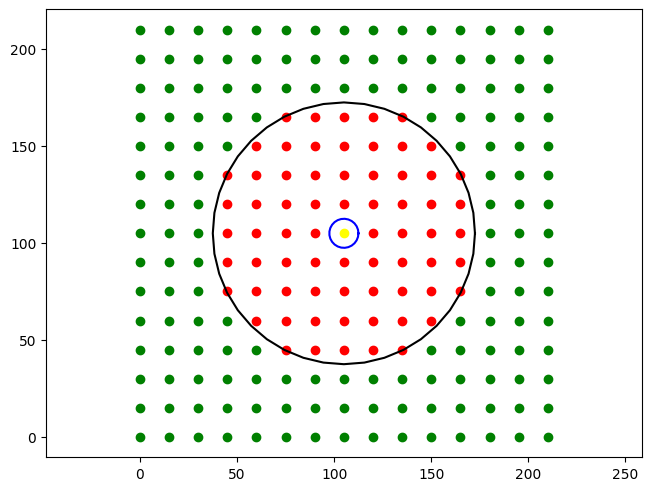

In [4]:
fig, axes = problem.plot_sketch()
out_path = Path(f"{data_folder}/{optimization_filename}/svgs/labeled_units.svg")
out_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out_path)

## Drawings reference geometry

In [5]:
# Retrieve geometry
geometry = problem.cloaked_geometry
# Select design variables
design_values = problem.horizontal_vertical_shifts_mg

generate_blocks_continuous_bond_lines_drawing(
    block_centroids=geometry.block_centroids(*design_values),
    centroid_node_vectors=geometry.centroid_node_vectors(*design_values),
    bond_connectivity=geometry.bond_connectivity(),
    reference_bond_vectors=geometry.reference_bond_vectors(),
    n1_blocks=geometry.n1_blocks,
    n2_blocks=geometry.n2_blocks,
    offset_type="constant",  # ["ratio", "constant"]
    offset_size=3, # mm
    path_orientation="column",
    out_file=f"{data_folder}/{optimization_filename}/svgs/reference_geometry.svg",
)


Design size is 222.75x222.75 mm
Saved at ../../../data/quads_shielding_multi_loading_source_3dp_pla_shims_4_loads/opt_integrated_with_angle_30_and_length_5_constraints_quads_15x15_amplitude_4.50_loading_rate_2.0_initial_angle_20.0_clamping_corners_True_damping_scaling_1.0/svgs/reference_geometry.svg


## Drawings cloak geometry

In [6]:
# Retrieve geometry
geometry = problem.cloaked_geometry
# Select design variables
design_values = optimization.design_values[-1]

generate_blocks_continuous_bond_lines_drawing(
    block_centroids=geometry.block_centroids(*problem.cloak_to_all_shifts(design_values)),
    centroid_node_vectors=geometry.centroid_node_vectors(*problem.cloak_to_all_shifts(design_values)),
    bond_connectivity=geometry.bond_connectivity(),
    reference_bond_vectors=geometry.reference_bond_vectors(),
    n1_blocks=problem.n1_blocks,
    n2_blocks=problem.n2_blocks,
    offset_type="ratio",  # ["ratio", "constant"]
    offset_size=0.7, # mm
    path_orientation="column",
    out_file=f"{data_folder}/{optimization_filename}/svgs/cloaked_geometry.svg",
)


Design size is 222.75x222.75 mm
Saved at ../../../data/quads_shielding_multi_loading_source_3dp_pla_shims_4_loads/opt_integrated_with_angle_30_and_length_5_constraints_quads_15x15_amplitude_4.50_loading_rate_2.0_initial_angle_20.0_clamping_corners_True_damping_scaling_1.0/svgs/cloaked_geometry.svg
